<a href="https://colab.research.google.com/github/harshithat29/internship/blob/main/vtu/week_8_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **HR Attrition Prediction Using Machine Learning Classification**

**Problem Statement**

Employee attrition is a critical issue for organizations, leading to increased hiring costs,
productivity loss, and reduced employee morale.

In this project, the goal is to build a Machine Learning classification model that predicts
whether an employee will leave the company (Attrition: Yes/No) based on features such as:

● Age

● Salary

● Job Role

● Job Satisfaction

● Work Experience

● Overtime

● Work-Life Balance

● Department

Students are required to analyze the dataset, preprocess the data, perform feature engineering,
train multiple classification models, and evaluate their performance to identify the best model for
predicting employee attrition.

**Objectives**

The objective of this task is to:

● Understand and explore the HR dataset

● Perform data preprocessing (missing values, duplicates, outliers)

● Conduct Exploratory Data Analysis (EDA)

● Apply encoding and feature scaling

● Train multiple classification algorithms

● Evaluate models using classification metrics

● Perform cross-validation and hyperparameter tuning

● Select the best-performing model

 1.Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

2.Load  the Dataset

In [ ]:
df = pd.read_csv("HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


3.Check Dataset

● Shape

● Columns

● Data types

● Summary statistics

In [ ]:
df.shape

(1470, 35)

In [ ]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [ ]:
df.dtypes

,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


In [ ]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


4.Handle Missing Values

In [ ]:
# Check missing values
df.isnull().sum()



,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


5. Remove Duplicate Records

In [ ]:
# Check duplicate records
df.duplicated().sum()

# Remove duplicates
df.drop_duplicates(inplace=True)

6.Perform Univariate Analysis


In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include='object').columns


* Distribution of numerical features

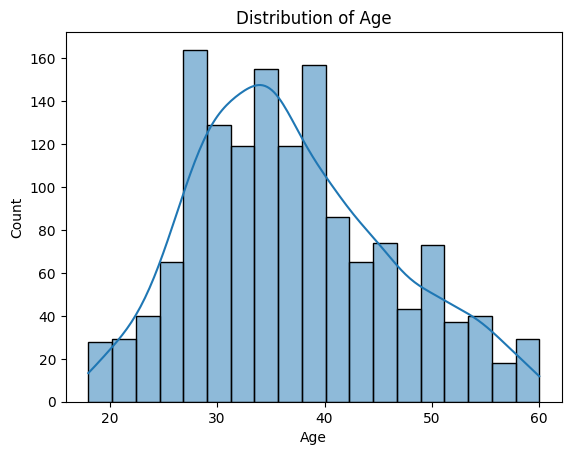

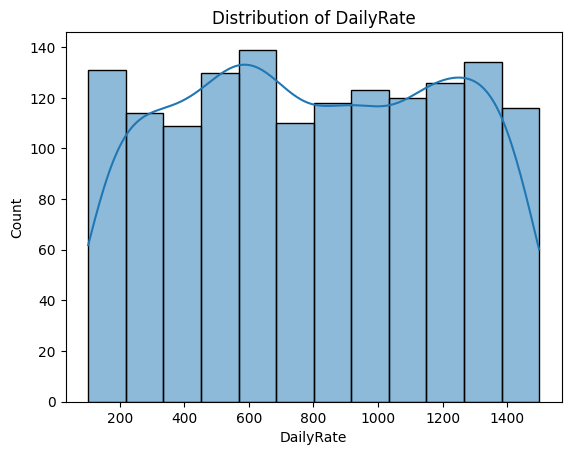

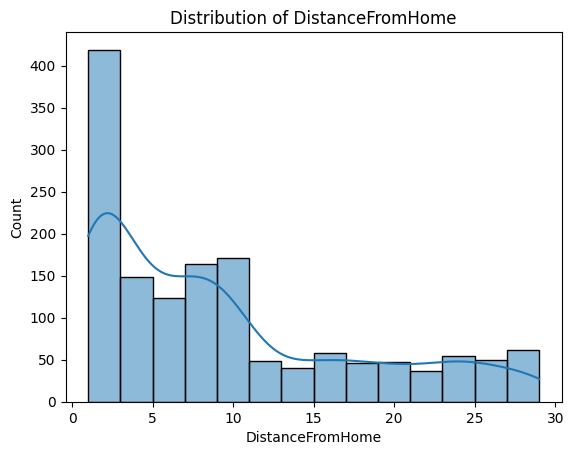

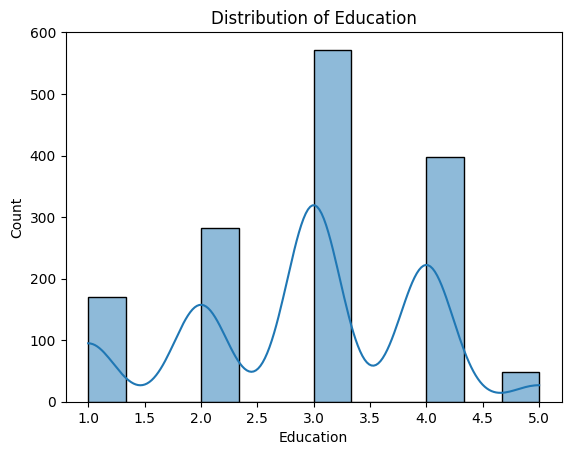

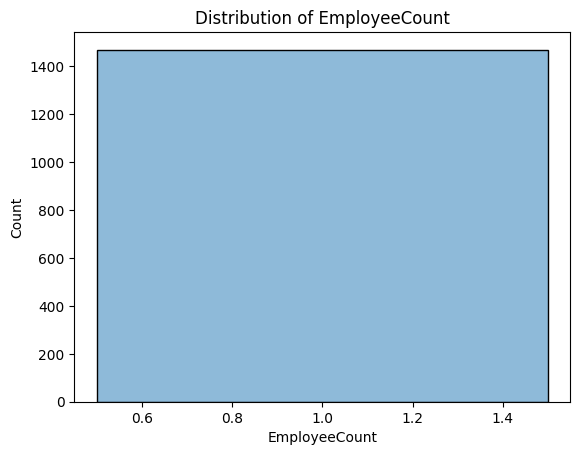

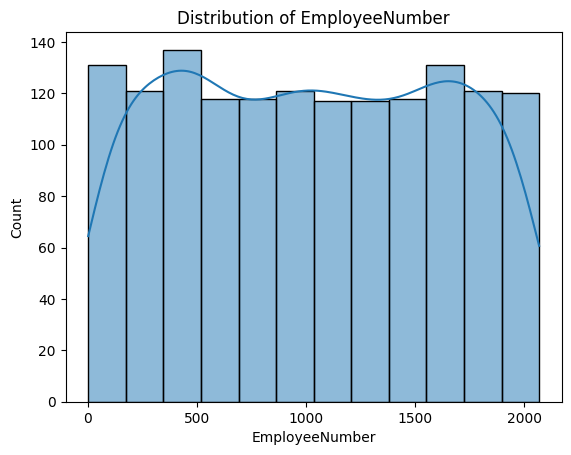

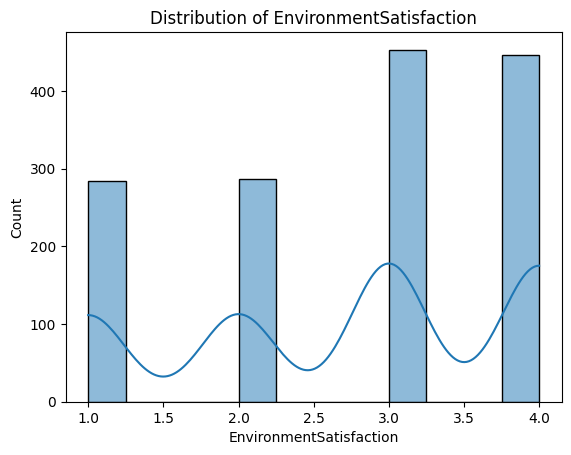

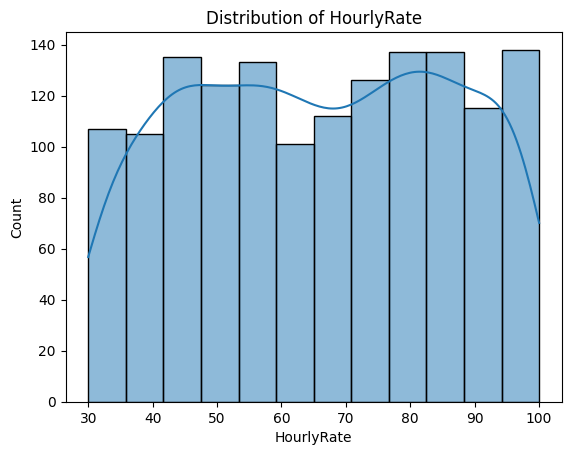

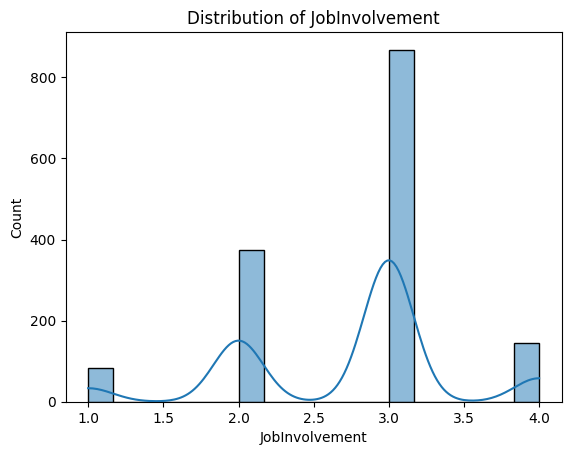

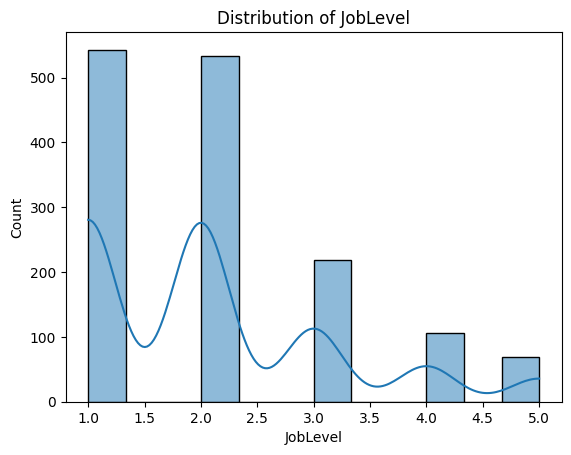

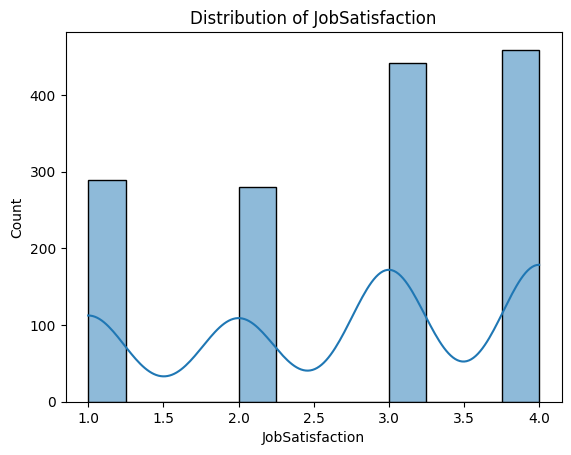

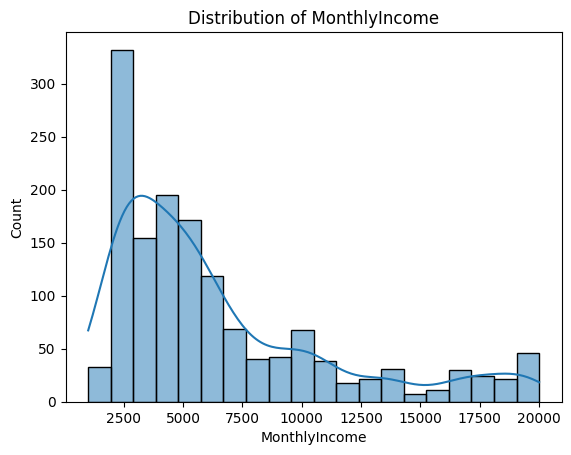

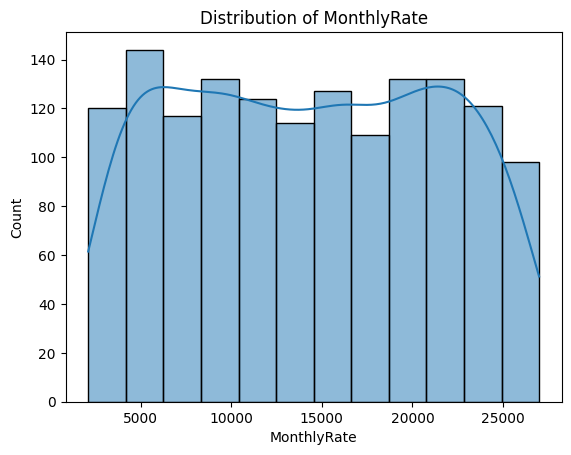

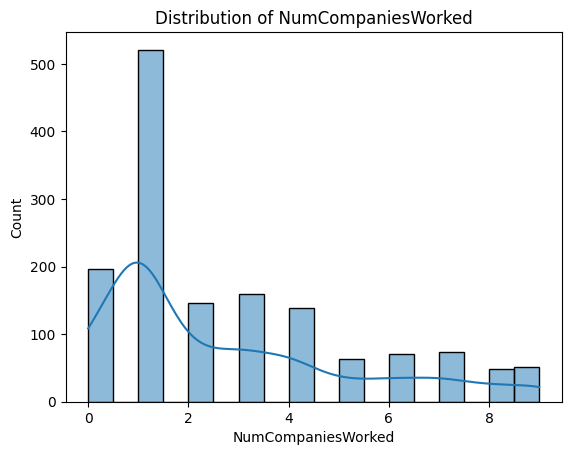

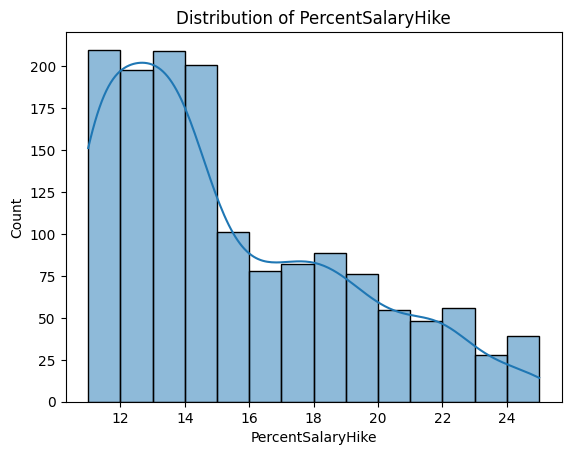

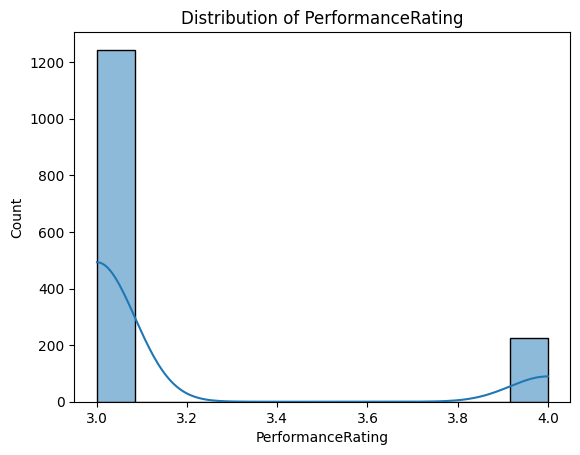

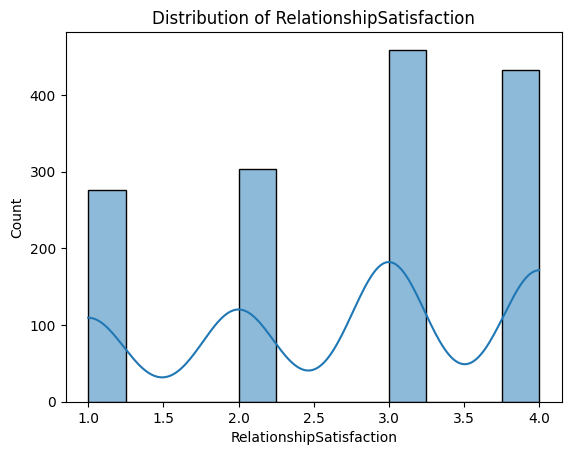

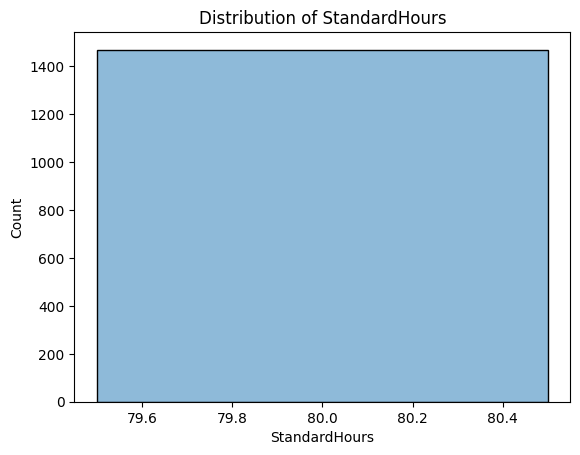

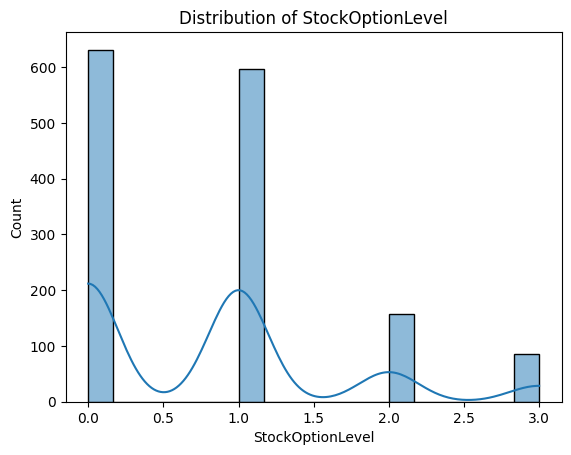

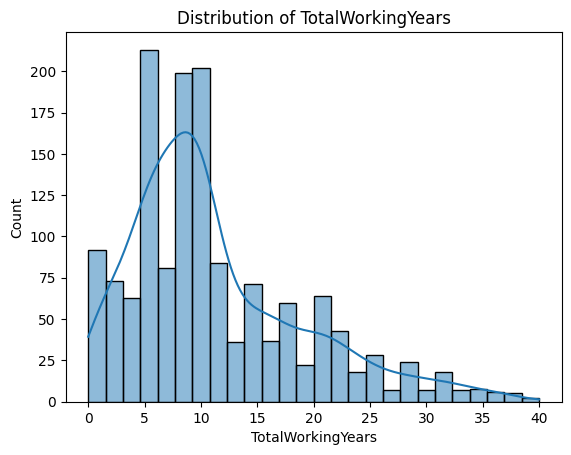

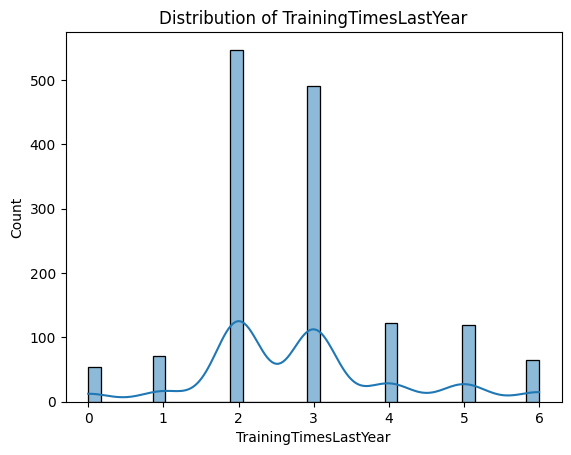

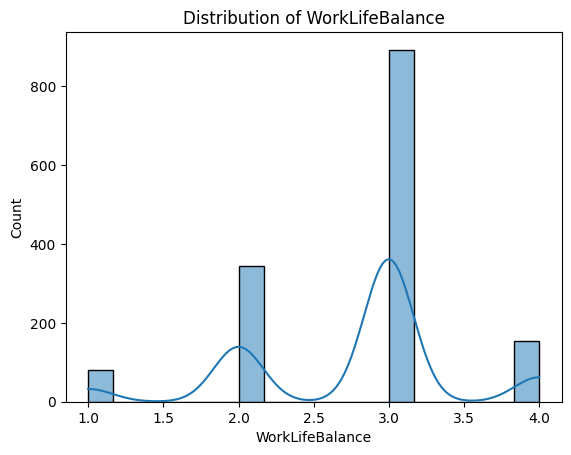

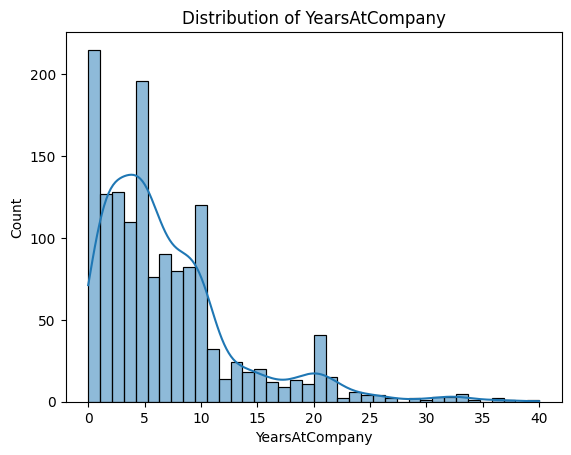

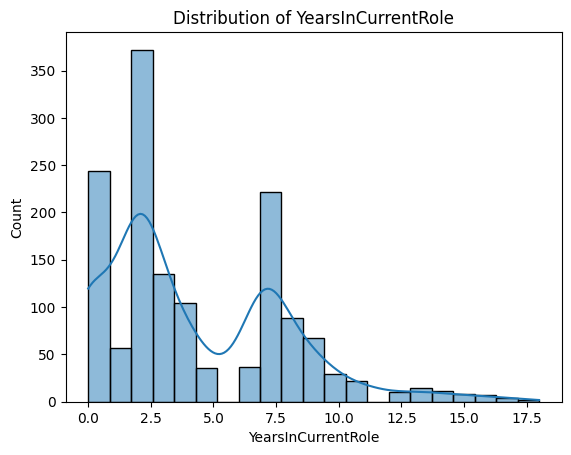

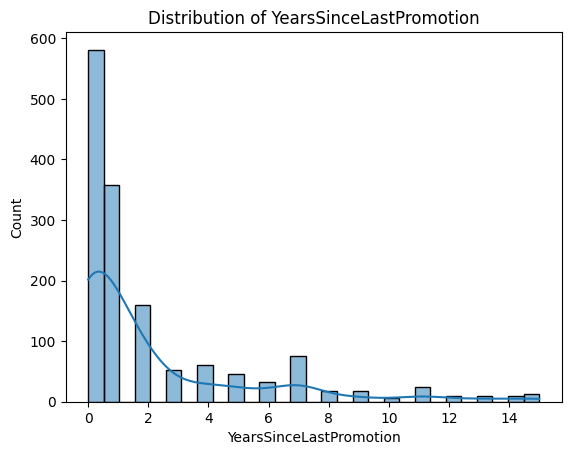

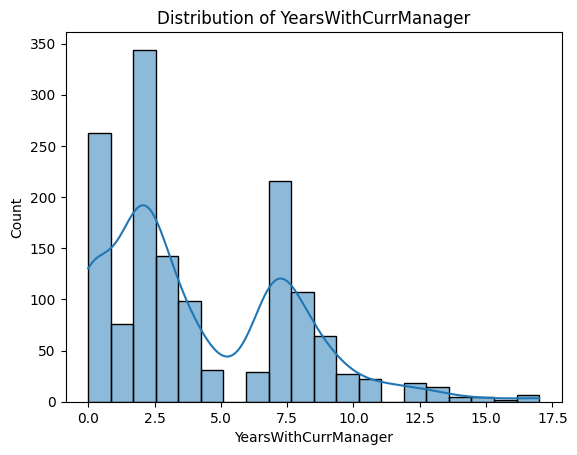

In [ ]:
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()


* Count plots for categorical features

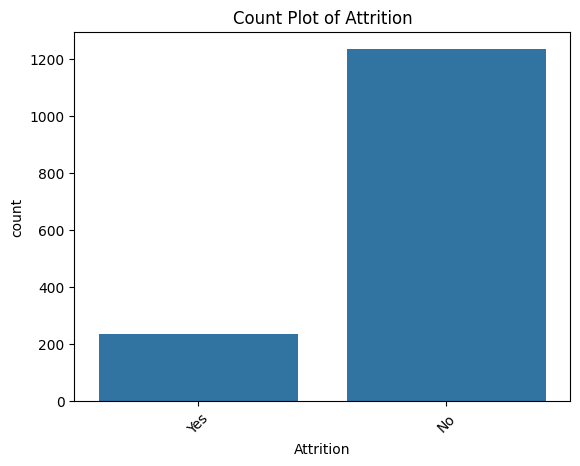

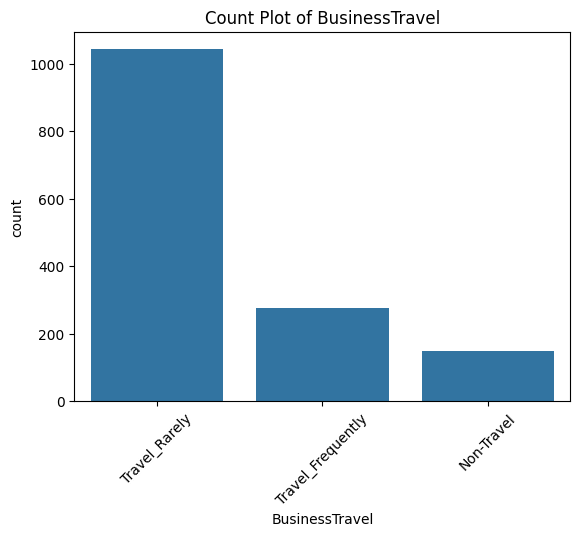

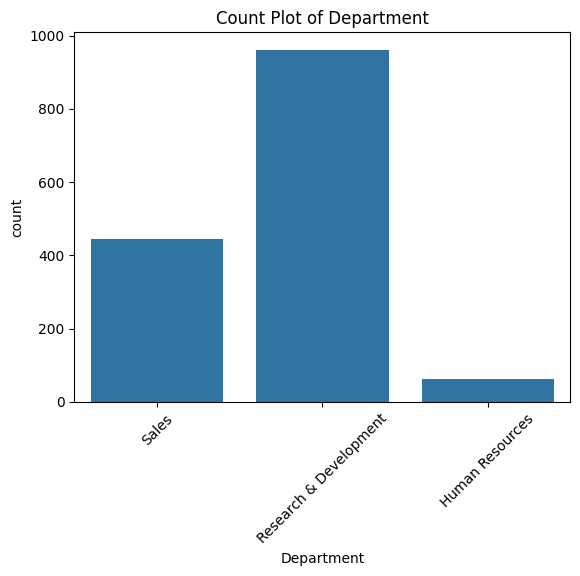

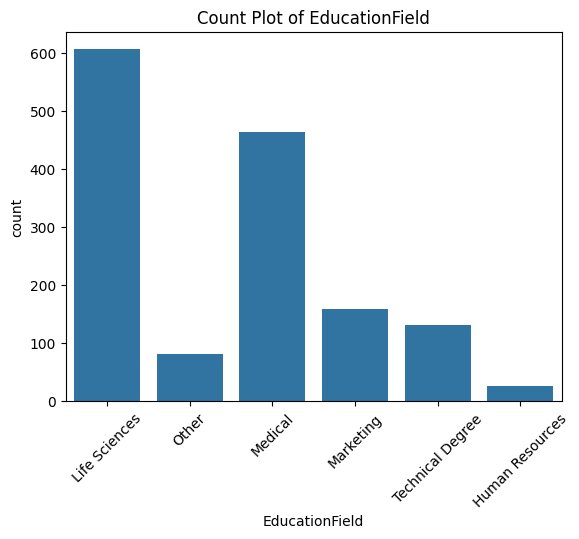

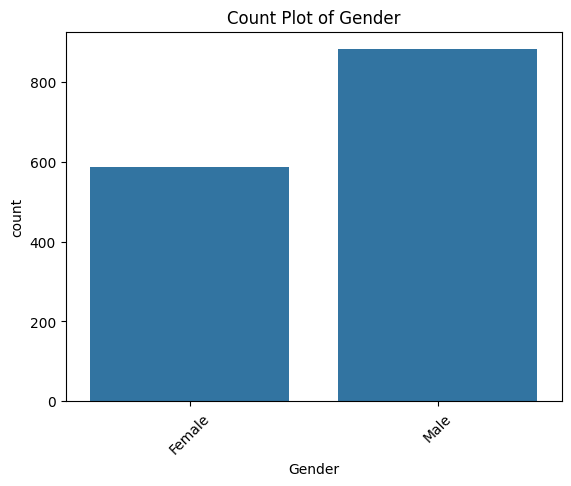

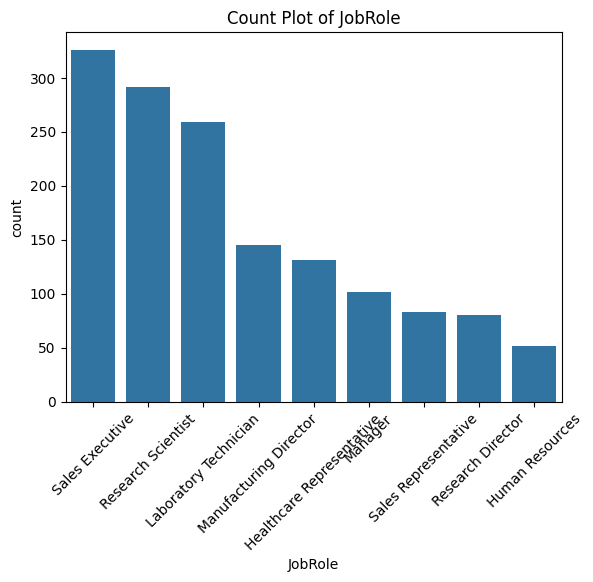

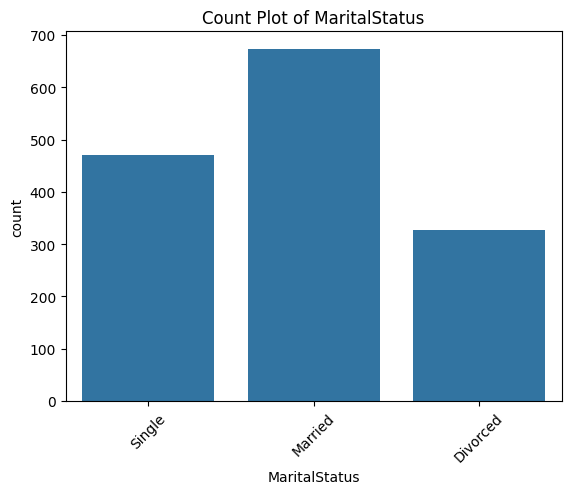

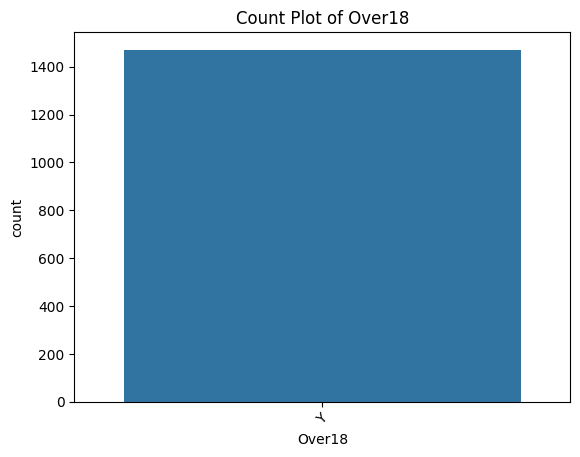

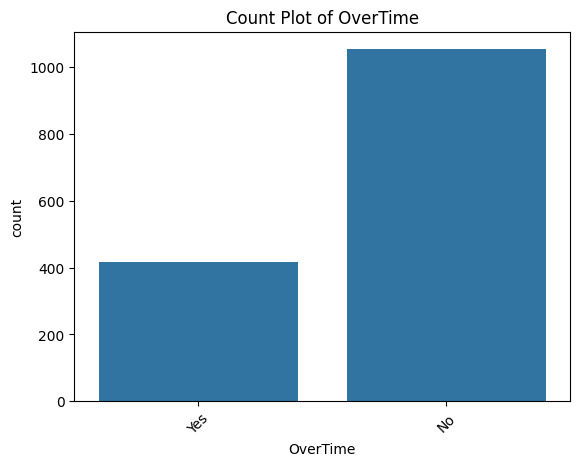

In [ ]:
for col in cat_cols:
    plt.figure()
    sns.countplot(x=df[col])
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45)
    plt.show()

7. Perform Bivariate Analysis

* Attrition vs categorical features

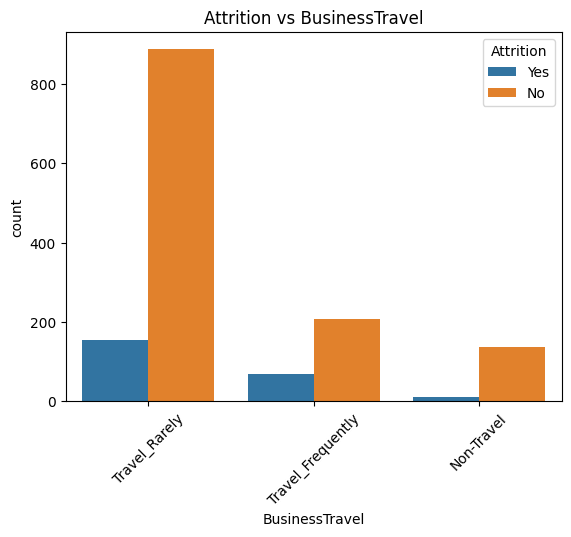

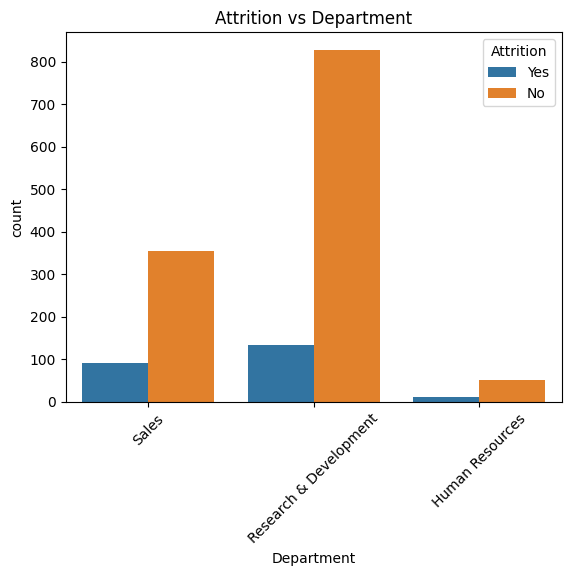

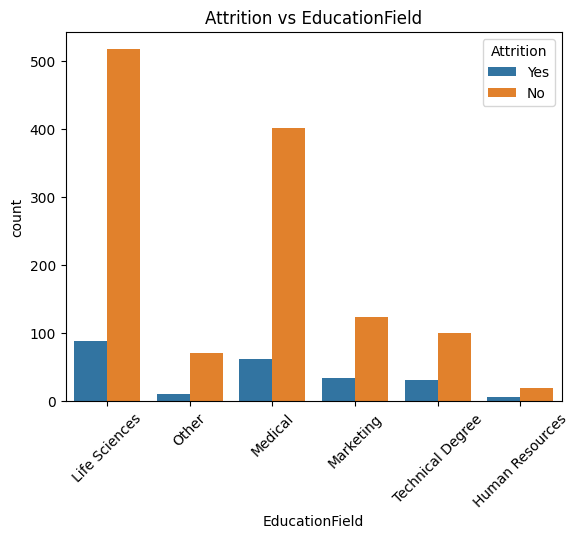

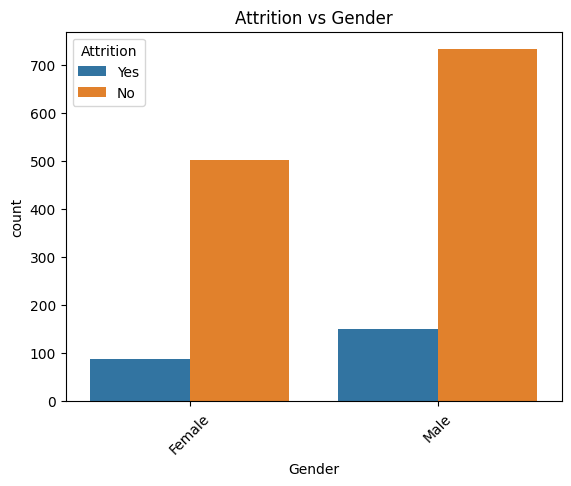

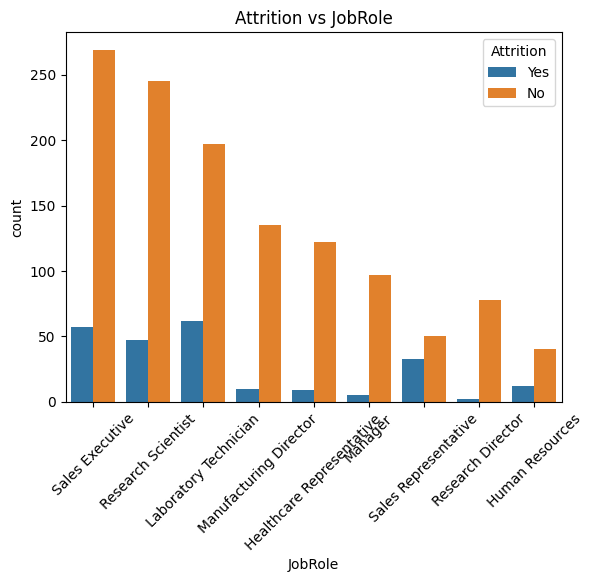

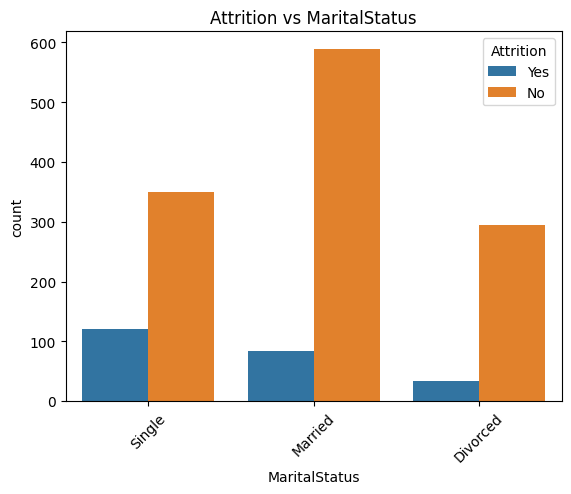

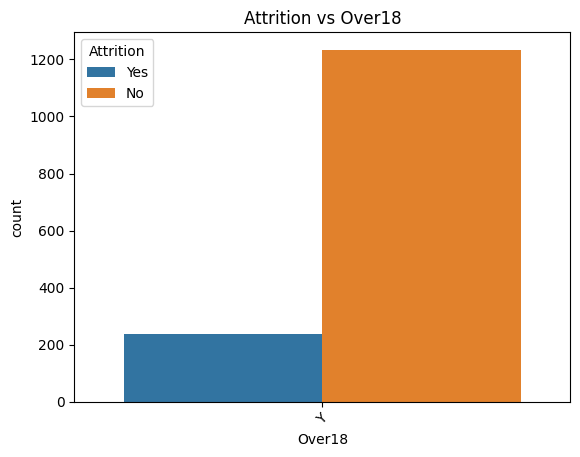

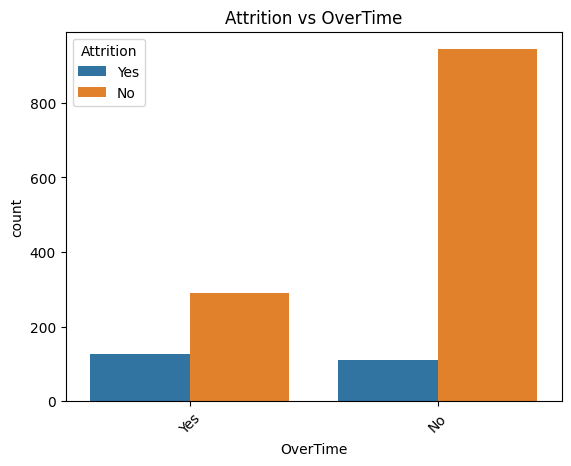

In [ ]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    if col != 'Attrition':
        plt.figure()
        sns.countplot(x=col, hue='Attrition', data=df)
        plt.title(f'Attrition vs {col}')
        plt.xticks(rotation=45)
        plt.show()


* Attrition vs numerical features

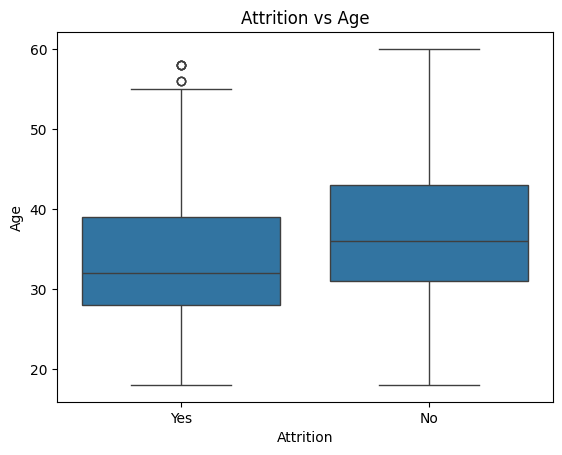

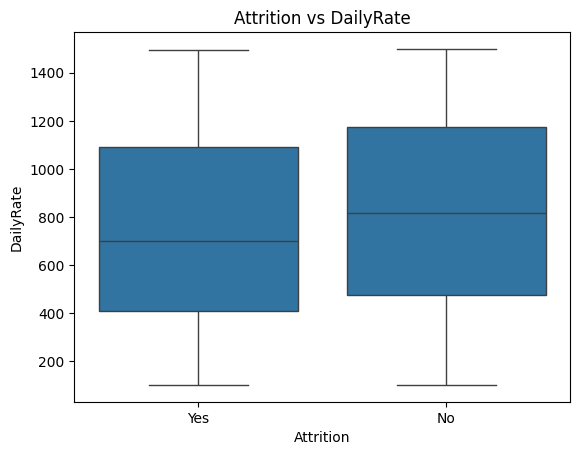

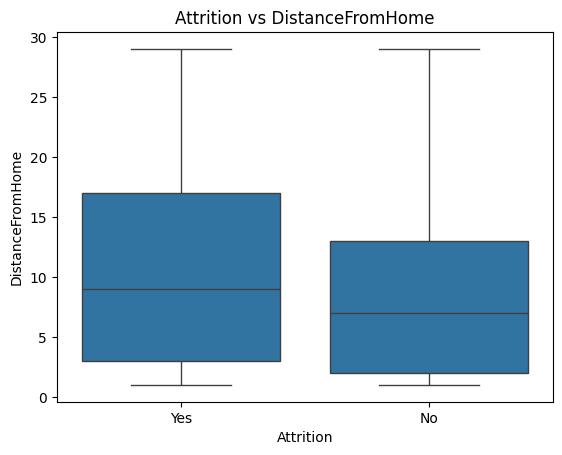

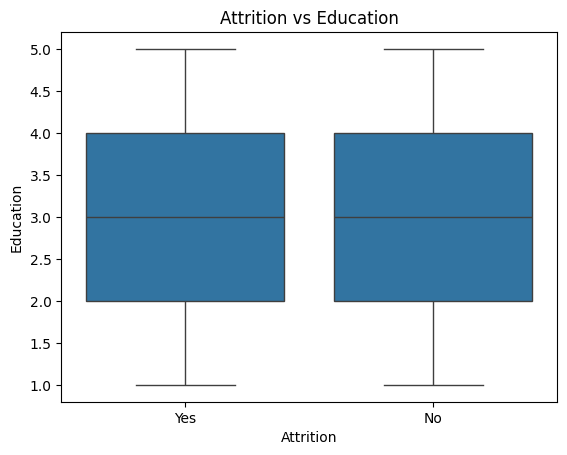

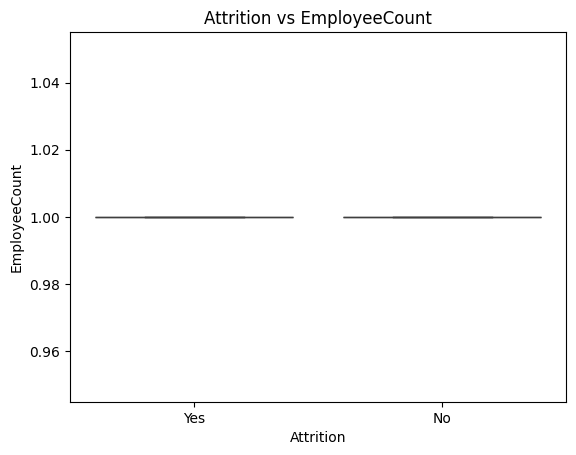

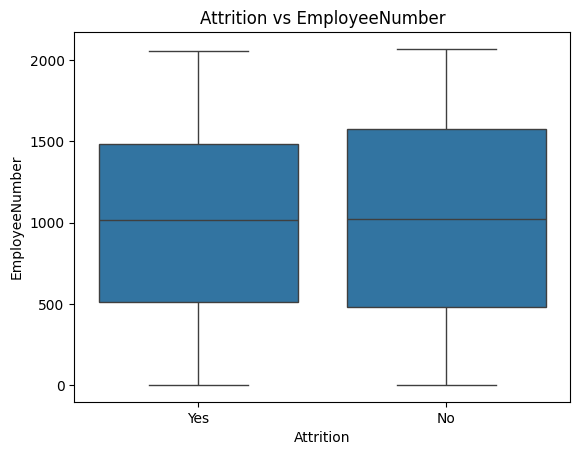

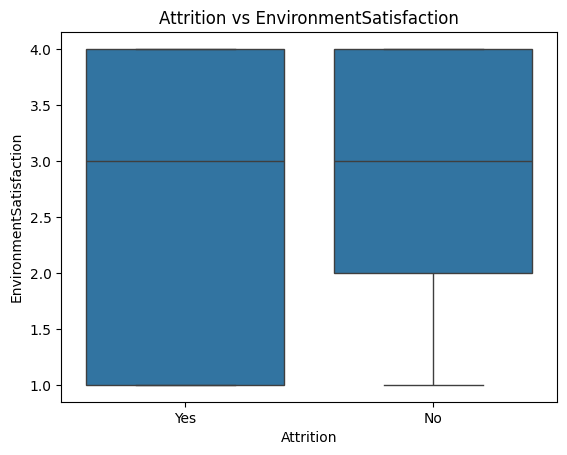

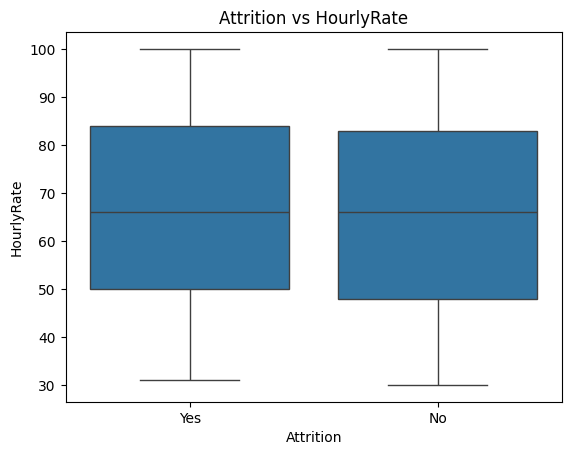

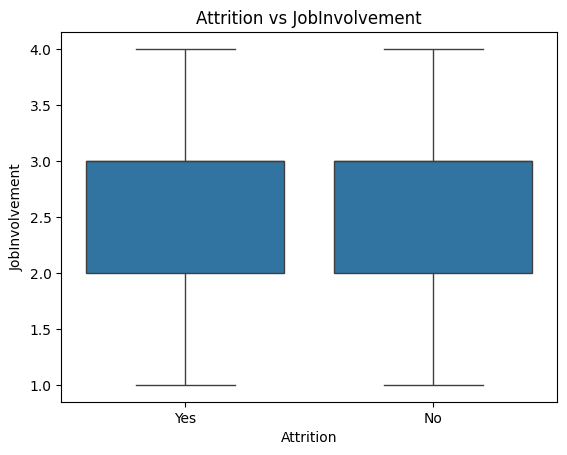

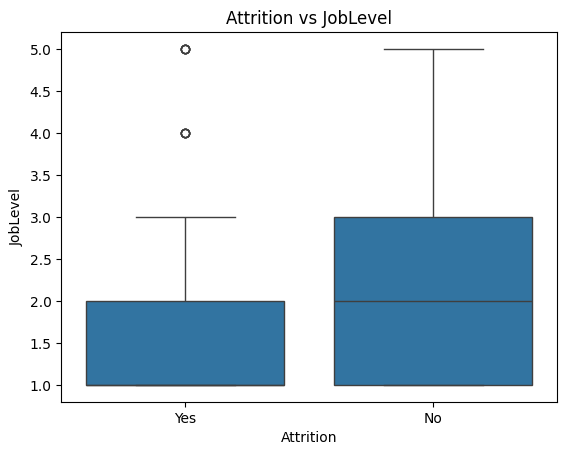

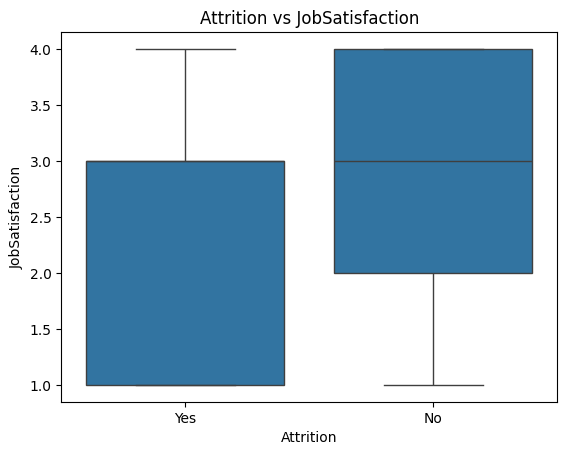

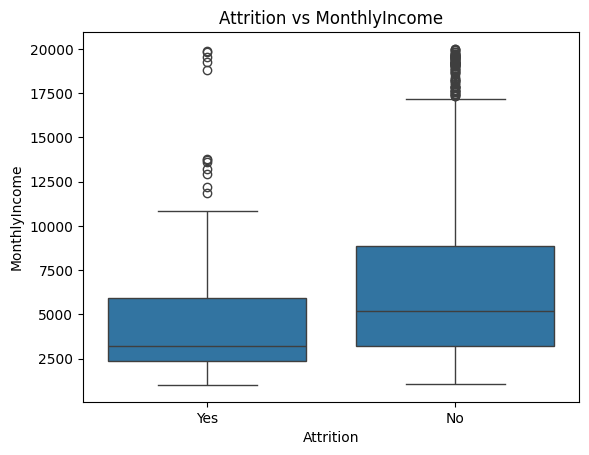

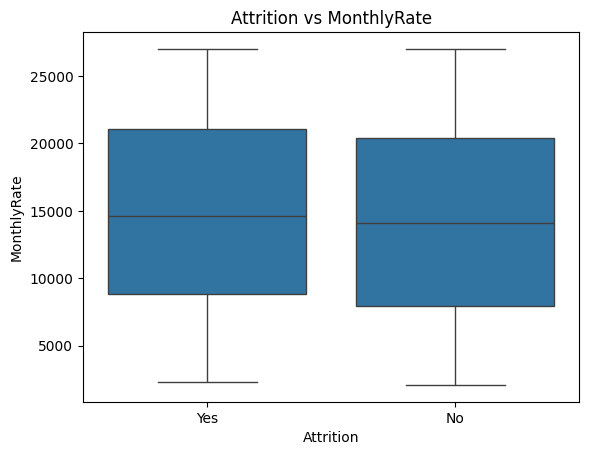

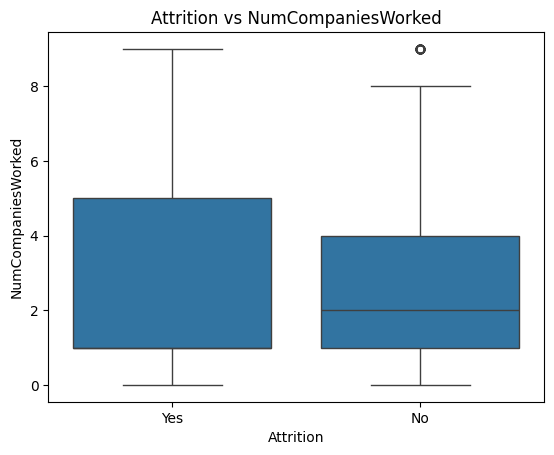

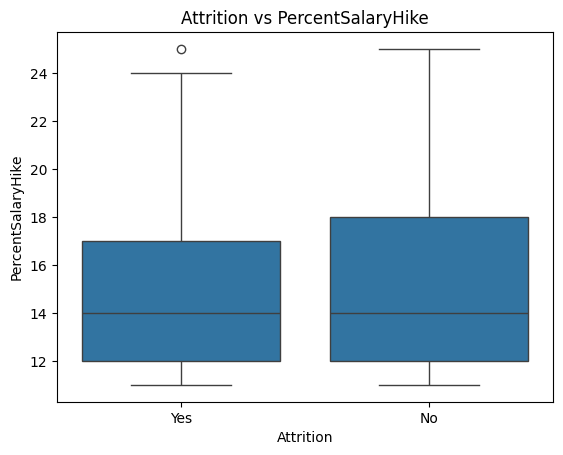

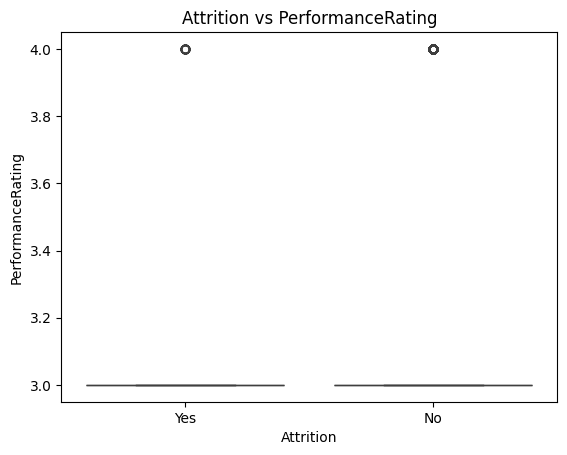

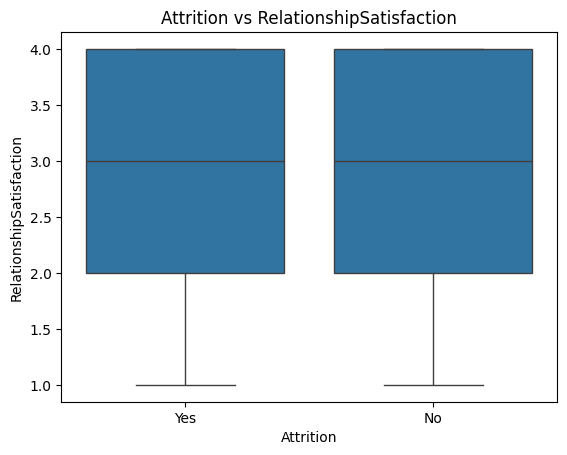

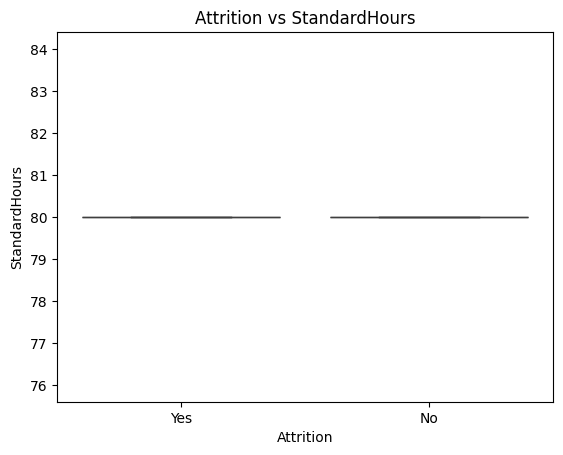

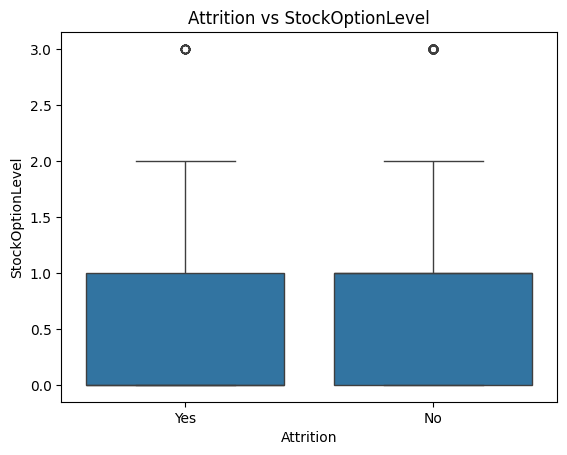

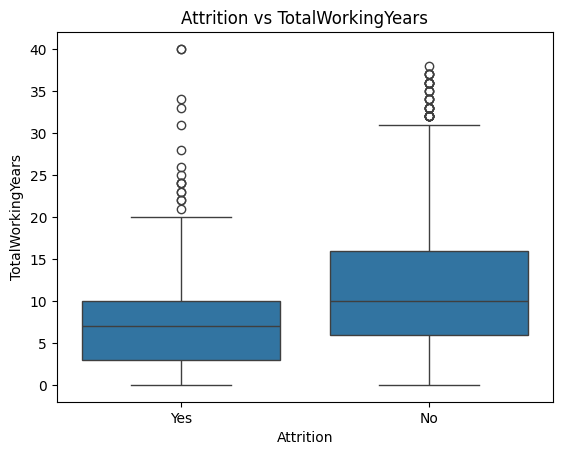

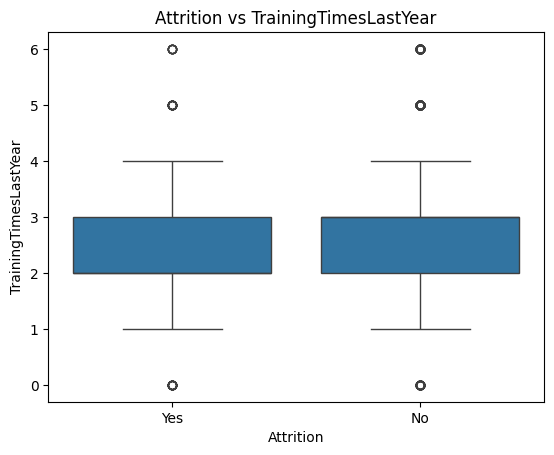

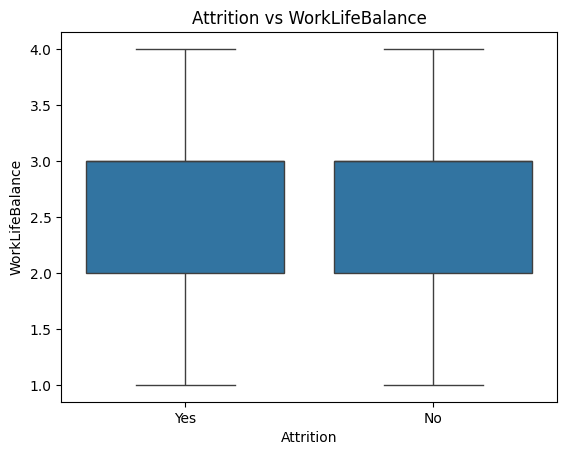

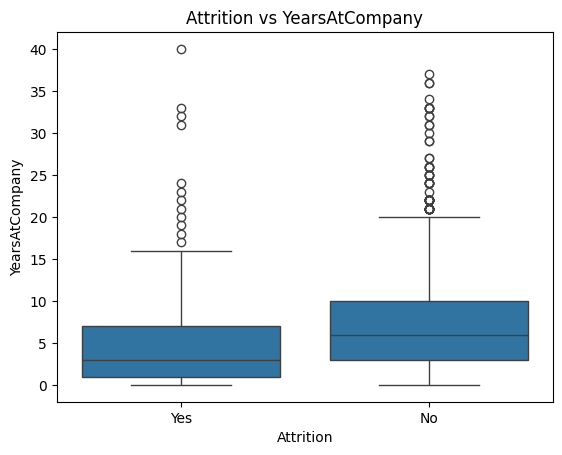

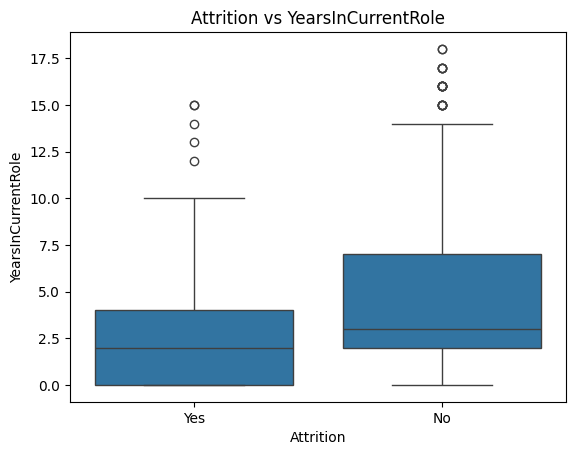

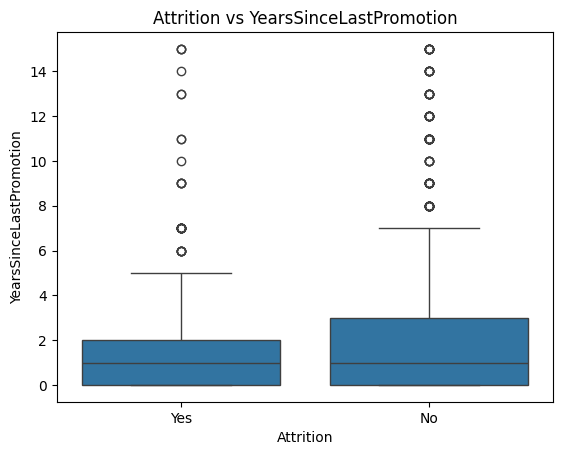

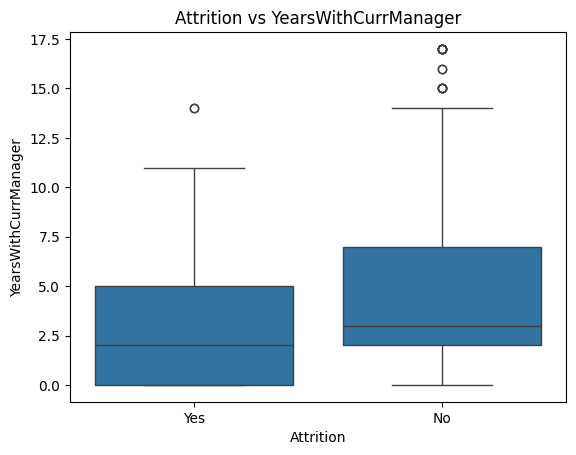

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure()
    sns.boxplot(x='Attrition', y=col, data=df)
    plt.title(f'Attrition vs {col}')
    plt.show()

8.Generate Correlation Heatmap

In [ ]:
df_clean = df.drop(['EmployeeCount', 'StandardHours'], axis=1, errors='ignore')

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df_clean.copy()
le = LabelEncoder()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

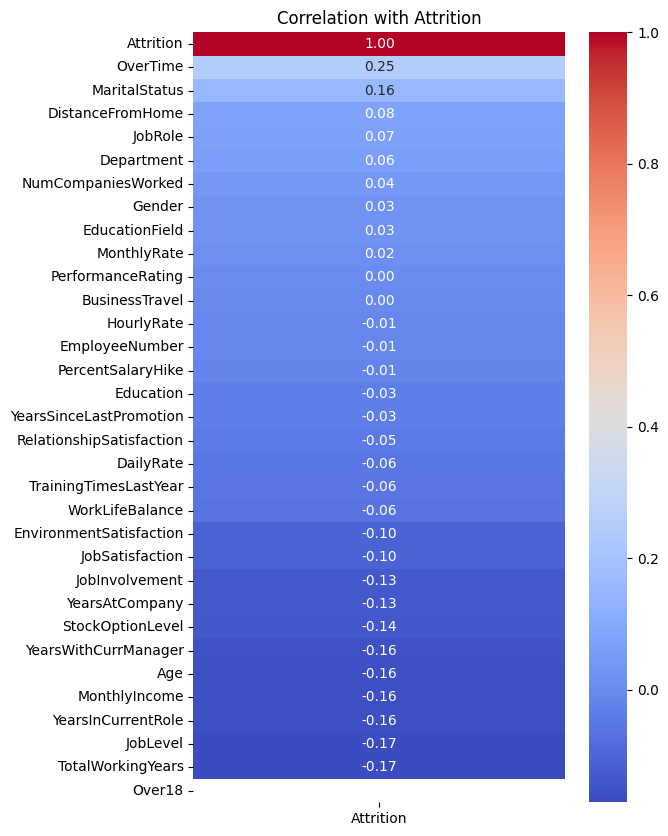

In [ ]:
corr = df_encoded.corr()

corr_target = corr[['Attrition']].sort_values(by='Attrition', ascending=False)

plt.figure(figsize=(6, 10))
sns.heatmap(corr_target, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation with Attrition")
plt.show()

9.Detect and Handle Outliers

* Detect Outliers (Using Boxplot)

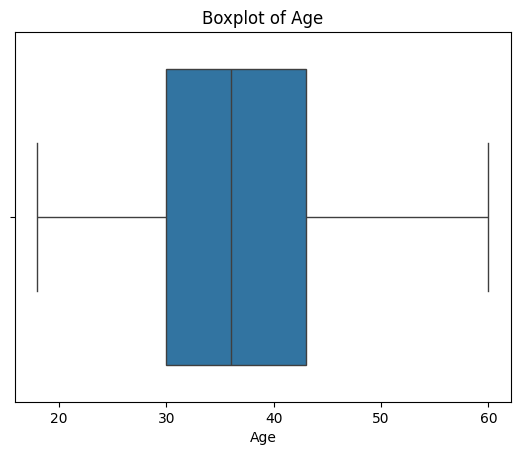

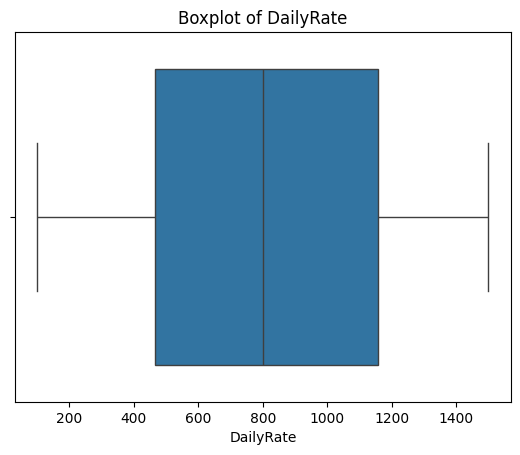

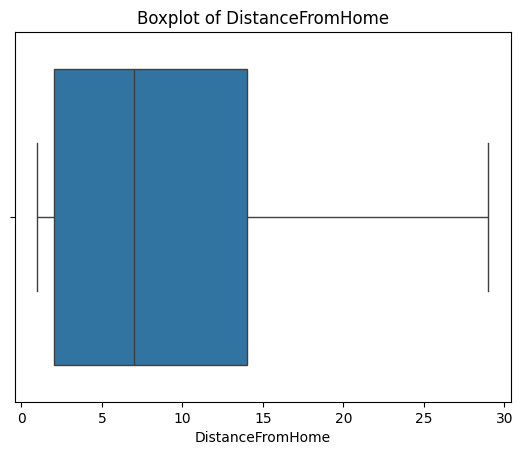

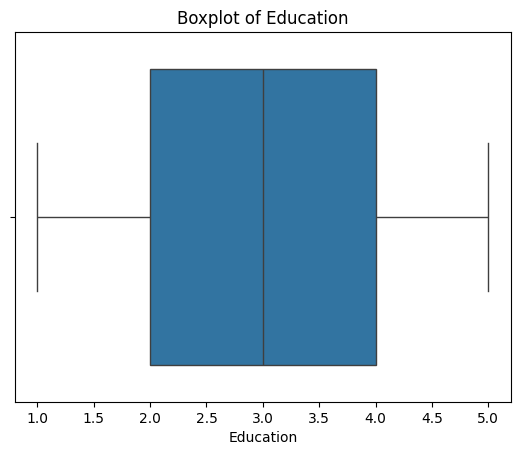

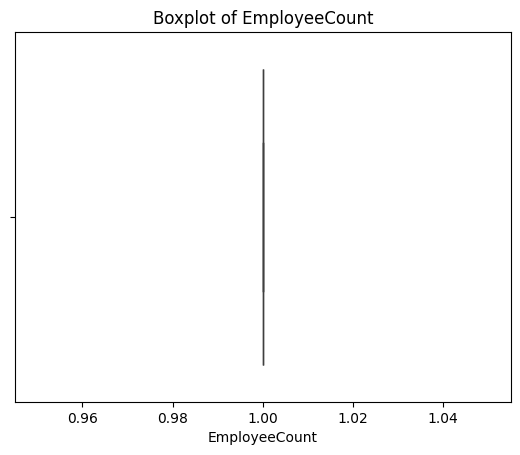

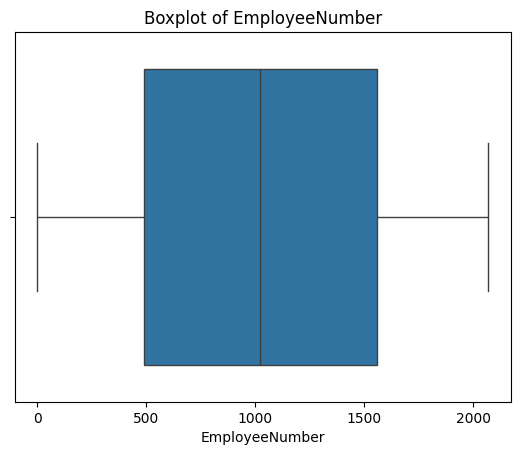

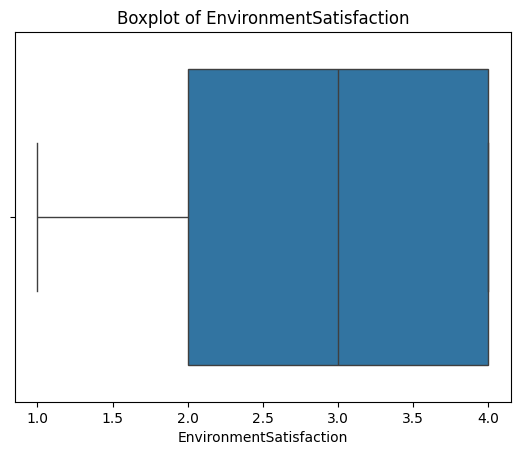

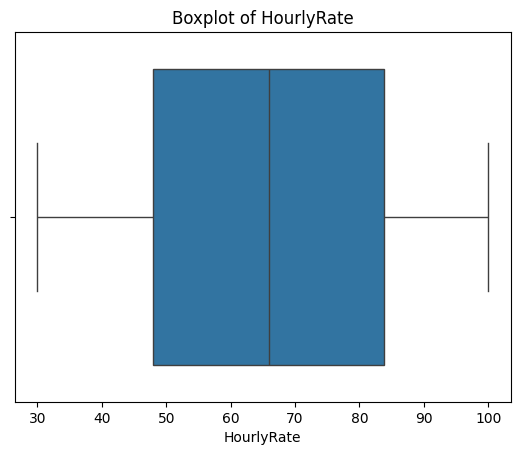

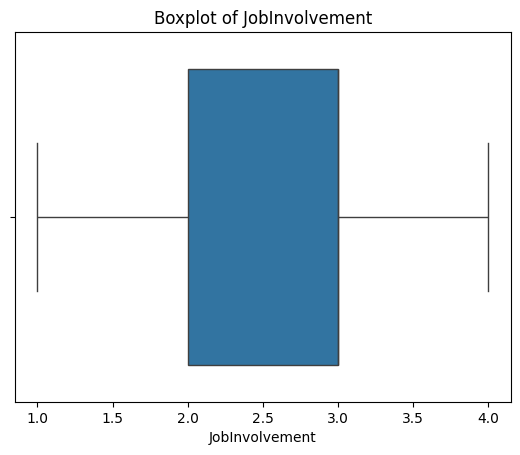

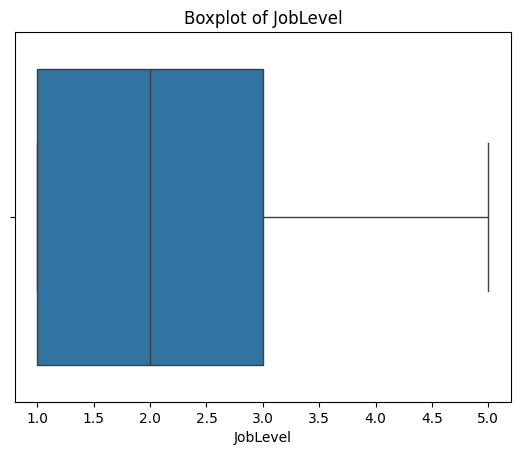

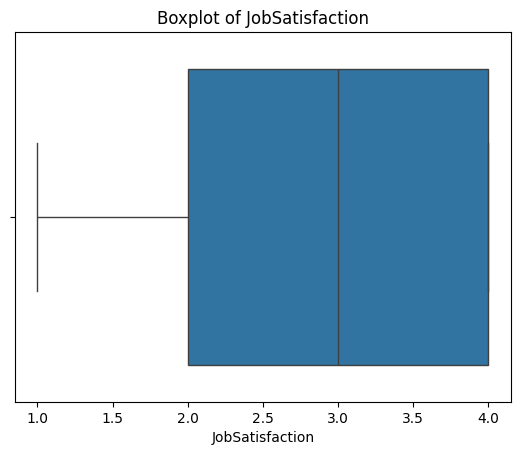

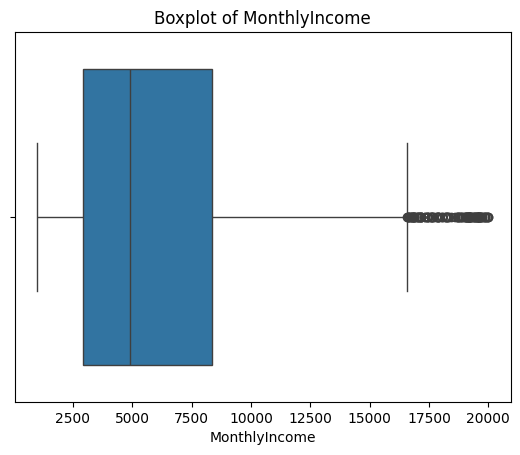

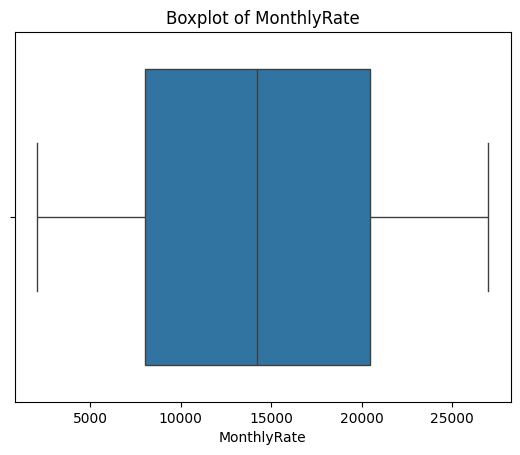

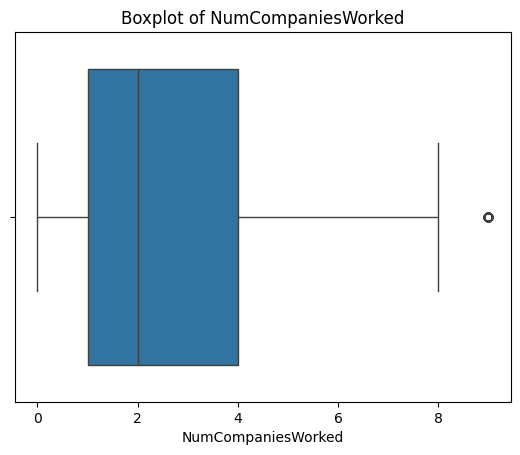

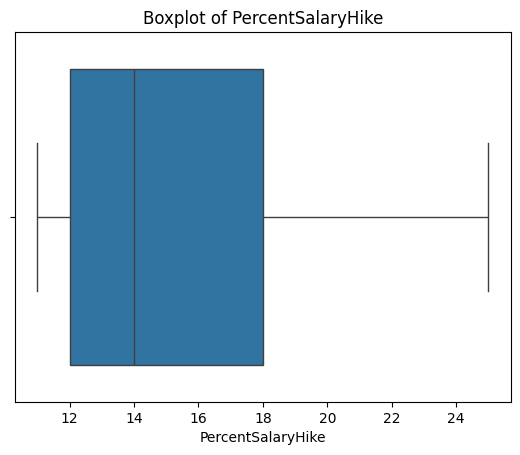

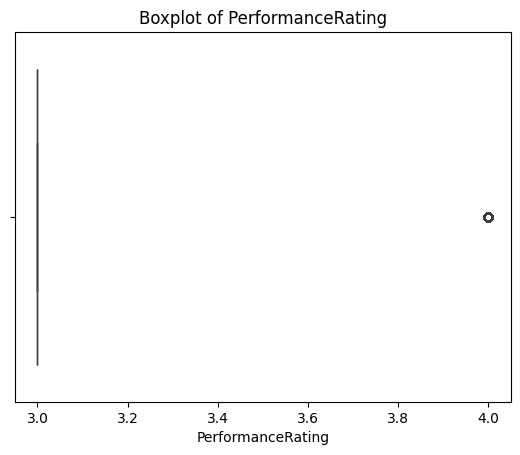

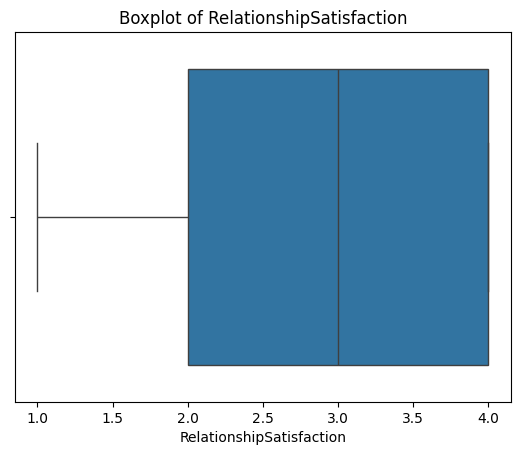

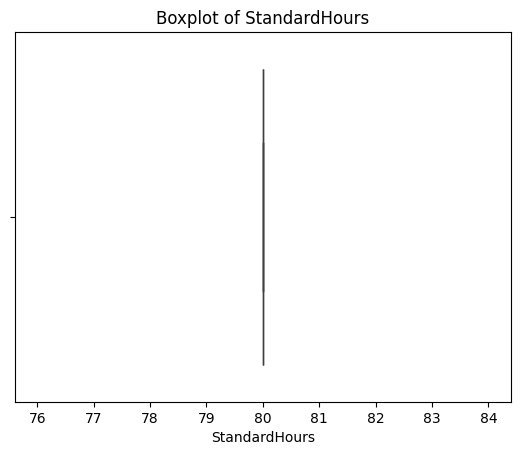

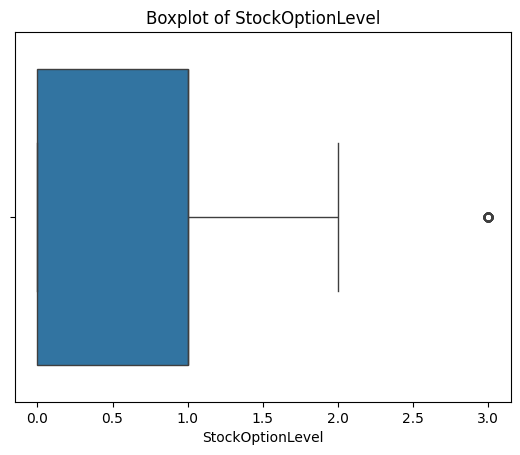

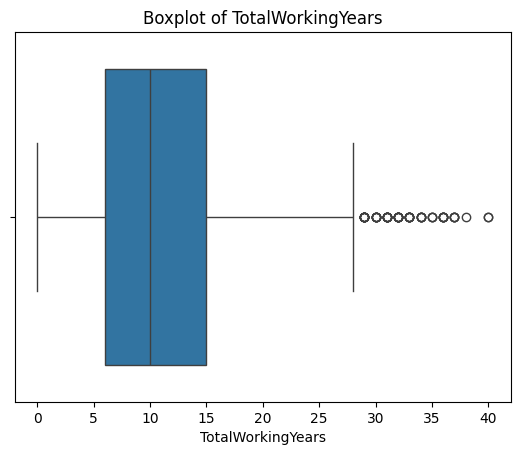

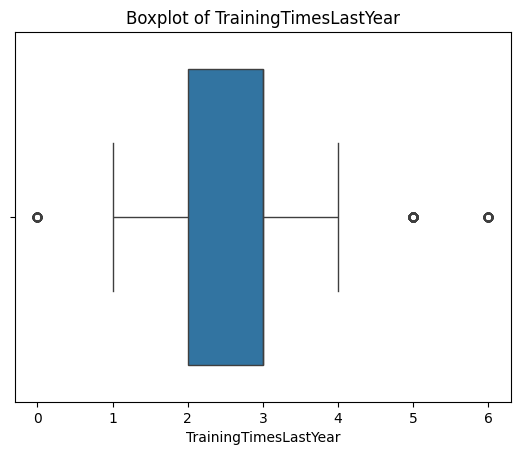

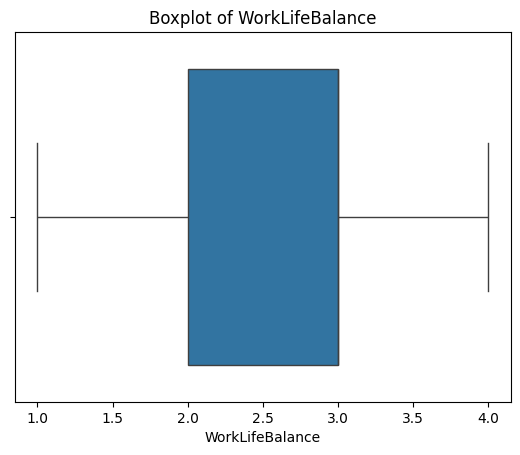

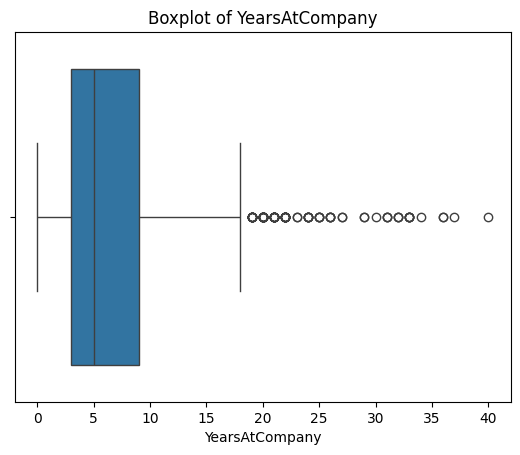

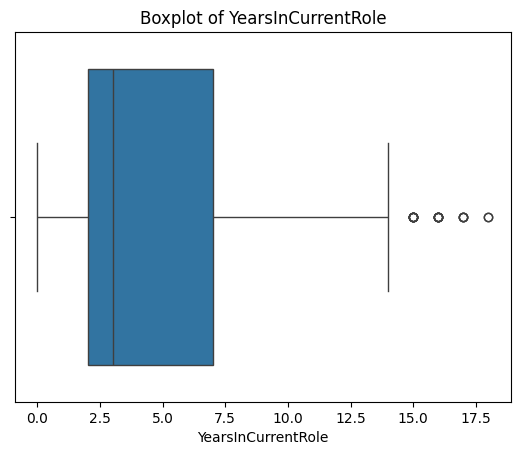

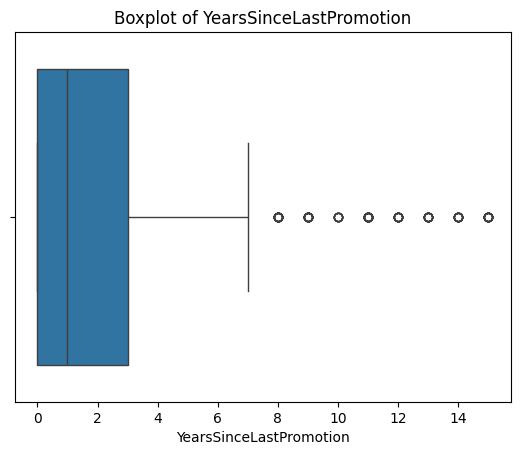

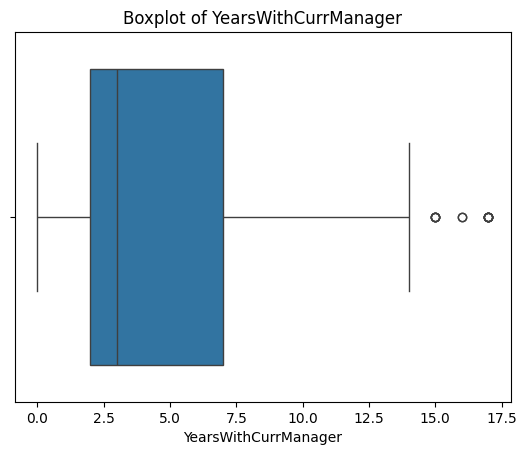

In [ ]:
# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Plot boxplots
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

* Handle Outliers (Using IQR Method)

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"🔹 Column: {col}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")
    print("-" * 40)

🔹 Column: Age
Q1: 30.0
Q3: 43.0
IQR: 13.0
Lower Bound: 10.5
Upper Bound: 62.5
----------------------------------------
🔹 Column: DailyRate
Q1: 465.0
Q3: 1157.0
IQR: 692.0
Lower Bound: -573.0
Upper Bound: 2195.0
----------------------------------------
🔹 Column: DistanceFromHome
Q1: 2.0
Q3: 14.0
IQR: 12.0
Lower Bound: -16.0
Upper Bound: 32.0
----------------------------------------
🔹 Column: Education
Q1: 2.0
Q3: 4.0
IQR: 2.0
Lower Bound: -1.0
Upper Bound: 7.0
----------------------------------------
🔹 Column: EmployeeCount
Q1: 1.0
Q3: 1.0
IQR: 0.0
Lower Bound: 1.0
Upper Bound: 1.0
----------------------------------------
🔹 Column: EmployeeNumber
Q1: 491.25
Q3: 1555.75
IQR: 1064.5
Lower Bound: -1105.5
Upper Bound: 3152.5
----------------------------------------
🔹 Column: EnvironmentSatisfaction
Q1: 2.0
Q3: 4.0
IQR: 2.0
Lower Bound: -1.0
Upper Bound: 7.0
----------------------------------------
🔹 Column: HourlyRate
Q1: 48.0
Q3: 83.75
IQR: 35.75
Lower Bound: -5.625
Upper Bound: 137.375
--

10.Apply Encoding

* Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Apply Label Encoding to target column (Attrition)
df['Attrition'] = le.fit_transform(df['Attrition'])

* One-Hot Encoding

In [ ]:
# Apply One-Hot Encoding to categorical columns
df = pd.get_dummies(df, drop_first=True)

11.Apply Scaling

* StandardScaler  

In [ ]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to DataFrame (for viewing output)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Show output
X_scaled.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,0.446350,0.590048,0.742527,1.401512,-1.010909,-0.891688,-0.937414,-1.701283,-0.660531,-1.224745,...,-0.426230,-1.584178,-0.932014,-0.421642,-2.171982,-2.493820,-0.164613,-0.063296,-0.679146,0.245834
1,1.322365,-0.913194,-1.297775,-0.493817,-0.147150,-1.868426,-0.937414,-1.699621,0.254625,0.816497,...,2.346151,1.191438,0.241988,-0.164511,0.155707,0.338096,0.488508,0.764998,-0.368715,0.806541
2,0.008343,0.590048,1.414363,-0.493817,-0.887515,-0.891688,1.316673,-1.696298,1.169781,0.816497,...,-0.426230,-0.658973,-0.932014,-0.550208,0.155707,0.338096,-1.144294,-1.167687,-0.679146,-1.155935
3,-0.429664,-0.913194,1.461466,-0.493817,-0.764121,1.061787,-0.937414,-1.694636,1.169781,-1.224745,...,-0.426230,0.266233,-0.932014,-0.421642,0.155707,0.338096,0.161947,0.764998,0.252146,-1.155935
4,-1.086676,0.590048,-0.524295,-0.493817,-0.887515,-1.868426,0.565311,-1.691313,-1.575686,0.816497,...,-0.426230,1.191438,0.241988,-0.678774,0.155707,0.338096,-0.817734,-0.615492,-0.058285,-0.595227


* MinMaxScaler

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Apply MinMaxScaler
minmax = MinMaxScaler()
X_minmax = minmax.fit_transform(X)

# Convert to DataFrame
X_minmax = pd.DataFrame(X_minmax, columns=X.columns)

# Show output
X_minmax.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,0.547619,1.0,0.715820,1.0,0.000000,0.25,0.2,0.000000,0.333333,0.0,...,0.0,0.000000,0.000000,0.200,0.0,0.000000,0.15,0.222222,0.000000,0.294118
1,0.738095,0.5,0.126700,0.5,0.250000,0.00,0.2,0.000484,0.666667,1.0,...,1.0,1.000000,0.333333,0.250,0.5,0.666667,0.25,0.388889,0.066667,0.411765
2,0.452381,1.0,0.909807,0.5,0.035714,0.25,0.8,0.001451,1.000000,1.0,...,0.0,0.333333,0.000000,0.175,0.5,0.666667,0.00,0.000000,0.000000,0.000000
3,0.357143,0.5,0.923407,0.5,0.071429,0.75,0.2,0.001935,1.000000,0.0,...,0.0,0.666667,0.000000,0.200,0.5,0.666667,0.20,0.388889,0.200000,0.000000
4,0.214286,1.0,0.350036,0.5,0.035714,0.00,0.6,0.002903,0.000000,1.0,...,0.0,1.000000,0.333333,0.150,0.5,0.666667,0.05,0.111111,0.133333,0.117647


11.Separate Features and Target Variable

● X → Features

● y → Attrition

In [ ]:
# Separate features (X) and target (y)

X = df_encoded.drop('Attrition', axis=1)  # Features
y = df_encoded['Attrition']               # Target variable

# Show output
print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   Age  BusinessTravel  DailyRate  Department  DistanceFromHome  Education  \
0   41               2       1102           2                 1          2   
1   49               1        279           1                 8          1   
2   37               2       1373           1                 2          2   
3   33               1       1392           1                 3          4   
4   27               2        591           1                 2          1   

   EducationField  EmployeeNumber  EnvironmentSatisfaction  Gender  ...  \
0               1               1                        2       0  ...   
1               1               2                        3       1  ...   
2               4               4                        4       1  ...   
3               1               5                        4       0  ...   
4               3               7                        1       1  ...   

   PerformanceRating  RelationshipSatisfaction  StockOptionLevel  

12.Perform Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Show output
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1176, 32)
X_test shape: (294, 32)
y_train shape: (1176,)
y_test shape: (294,)


12.Balance data : SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Check new shape
print("Before SMOTE:", X_train.shape, y_train.shape)
print("After SMOTE:", X_train_smote.shape, y_train_smote.shape)

Before SMOTE: (1176, 32) (1176,)
After SMOTE: (1956, 32) (1956,)


In [ ]:
print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_smote.value_counts())

Before SMOTE:
 Attrition
0    978
1    198
Name: count, dtype: int64

After SMOTE:
 Attrition
0    978
1    978
Name: count, dtype: int64


15. Train Classification Models



* Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_smote, y_train_smote)

y_pred_lr = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


* Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train_smote, y_train_smote)

y_pred_dt = dt.predict(X_test)

* Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)

* Gradient Boosting Classifier

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train_smote, y_train_smote)

y_pred_gb = gb.predict(X_test)

* XGBoost Classifier

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:57:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


* KNN Classifier

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train_smote, y_train_smote)

y_pred_knn = knn.predict(X_test)

* SVM Classifier

In [ ]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train_smote, y_train_smote)

y_pred_svm = svm.predict(X_test)

16.Evaluate Models Using

● Accuracy

● Precision

● Recall

● F1 Score

● ROC-AUC Score

● Confusion Matrix

In [ ]:
# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [ ]:
from sklearn.linear_model import LogisticRegression

# Train model
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_smote, y_train_smote)

# Create prediction (THIS was missing ❗)
y_pred_lr = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
models_predictions = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb,
    "XGBoost": y_pred_xgb,
    "KNN": y_pred_knn,
    "SVM": y_pred_svm
}

for name, y_pred in models_predictions.items():
    print(f"🔹 {name}")

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))

    # ROC-AUC (only works for binary classification)
    print("ROC-AUC:", roc_auc_score(y_test, y_pred))

    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("-" * 50)

🔹 Logistic Regression
Accuracy: 0.7210884353741497
Precision: 0.19718309859154928
Recall: 0.358974358974359
F1 Score: 0.2545454545454545
ROC-AUC: 0.5677224736048265
Confusion Matrix:
 [[198  57]
 [ 25  14]]
--------------------------------------------------
🔹 Decision Tree
Accuracy: 0.7380952380952381
Precision: 0.1935483870967742
Recall: 0.3076923076923077
F1 Score: 0.2376237623762376
ROC-AUC: 0.5558069381598794
Confusion Matrix:
 [[205  50]
 [ 27  12]]
--------------------------------------------------
🔹 Random Forest
Accuracy: 0.8775510204081632
Precision: 0.5555555555555556
Recall: 0.38461538461538464
F1 Score: 0.45454545454545453
ROC-AUC: 0.6687782805429864
Confusion Matrix:
 [[243  12]
 [ 24  15]]
--------------------------------------------------
🔹 Gradient Boosting
Accuracy: 0.8503401360544217
Precision: 0.43243243243243246
Recall: 0.41025641025641024
F1 Score: 0.42105263157894735
ROC-AUC: 0.6639517345399698
Confusion Matrix:
 [[234  21]
 [ 23  16]]
----------------------------

17.Perform Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "XGBoost": xgb,
    "KNN": knn,
    "SVM": svm
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

    print(f"🔹 {name}")
    print("CV Scores:", scores)
    print("Mean CV Score:", scores.mean())
    print("-" * 50)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

🔹 Logistic Regression
CV Scores: [0.82312925 0.85714286 0.86054422 0.8537415  0.85714286]
Mean CV Score: 0.8503401360544217
--------------------------------------------------
🔹 Decision Tree
CV Scores: [0.7755102  0.76190476 0.82312925 0.76190476 0.78571429]
Mean CV Score: 0.7816326530612244
--------------------------------------------------
🔹 Random Forest
CV Scores: [0.86054422 0.86394558 0.86394558 0.86054422 0.86394558]
Mean CV Score: 0.8625850340136054
--------------------------------------------------
🔹 Gradient Boosting
CV Scores: [0.84693878 0.8707483  0.87414966 0.8537415  0.86054422]
Mean CV Score: 0.8612244897959183
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:02:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:02:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:02:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:02:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

🔹 XGBoost
CV Scores: [0.85714286 0.86054422 0.86054422 0.86394558 0.85714286]
Mean CV Score: 0.8598639455782312
--------------------------------------------------
🔹 KNN
CV Scores: [0.81632653 0.82312925 0.82653061 0.81632653 0.82312925]
Mean CV Score: 0.8210884353741497
--------------------------------------------------
🔹 SVM
CV Scores: [0.83673469 0.83673469 0.84013605 0.84013605 0.84013605]
Mean CV Score: 0.8387755102040817
--------------------------------------------------


18. Apply Hyperparameter Tuning

1. GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

# Example: Random Forest
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_smote, y_train_smote)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

# Best model
best_rf = grid.best_estimator_

Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Best Score: 0.897325016963307


2. RandomizedSearchCV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

random = RandomizedSearchCV(RandomForestClassifier(), param_dist,
                            n_iter=5, cv=5, scoring='accuracy', random_state=42)

random.fit(X_train_smote, y_train_smote)

print("Best Parameters:", random.best_params_)
print("Best Score:", random.best_score_)

# Best model
best_rf_random = random.best_estimator_

Best Parameters: {'n_estimators': 50, 'min_samples_split': 5, 'max_depth': 30}
Best Score: 0.8845464272665587


19.Compare Model Performance

* Create Comparison Table

In [ ]:
import pandas as pd

# Store results
results = []

models_predictions = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb,
    "XGBoost": y_pred_xgb,
    "KNN": y_pred_knn,
    "SVM": y_pred_svm
}

for name, y_pred in models_predictions.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_pred)
    })

# Create DataFrame
results_df = pd.DataFrame(results)

# Display table
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.721088   0.197183  0.358974  0.254545  0.567722
1        Decision Tree  0.738095   0.193548  0.307692  0.237624  0.555807
2        Random Forest  0.877551   0.555556  0.384615  0.454545  0.668778
3    Gradient Boosting  0.850340   0.432432  0.410256  0.421053  0.663952
4              XGBoost  0.860544   0.466667  0.358974  0.405797  0.648115
5                  KNN  0.632653   0.158416  0.410256  0.228571  0.538462
6                  SVM  0.585034   0.168000  0.538462  0.256098  0.565309


* Identify Best Model

In [ ]:
# Sort by F1 Score (recommended for imbalanced data)
best_model = results_df.sort_values(by="F1 Score", ascending=False).iloc[0]

print("Best Model:")
print(best_model)

Best Model:
Model        Random Forest
Accuracy          0.877551
Precision         0.555556
Recall            0.384615
F1 Score          0.454545
ROC-AUC           0.668778
Name: 2, dtype: object


20. Select Best Model

● Based on metrics

● Business interpretation

In [ ]:
# Select best model based on F1 Score
best_model = results_df.sort_values(by="F1 Score", ascending=False).iloc[0]

print("Best Model Details:\n")
print(best_model)

Best Model Details:

Model        Random Forest
Accuracy          0.877551
Precision         0.555556
Recall            0.384615
F1 Score          0.454545
ROC-AUC           0.668778
Name: 2, dtype: object


21. Final Insights

● Key factors influencing attrition



From the analysis and model results, the most impactful factors are:

* Overtime → Employees working frequent overtime show higher attrition

* Job Satisfaction → Lower satisfaction strongly increases the chance of leaving

* Monthly Income (Salary) → Lower pay is linked to higher attrition

* Work-Life Balance → Poor balance leads to employee burnout and exits

* Total Working Years / Experience → Early-career employees are more likely to leave

* Department & Job Role → Certain roles/departments experience higher turnover

These features showed stronger influence in correlation analysis and model performance.

* Business Recommendations

Based on these insights, organizations can take the following actions:

*Reduce Overtime Load

→ Implement better workload planning and flexible schedules

*Improve Job Satisfaction

→ Conduct regular feedback surveys and address employee concerns

*Enhance Compensation Structure

→ Offer competitive salaries, bonuses, and incentives

*Promote Work-Life Balance

→ Introduce hybrid work, leave policies, and wellness programs

*Focus on High-Risk Employees

→ Use the model to identify and support employees likely to leave

*Department-Level Strategies

 → Take targeted actions in departments with high attrition

**Conclusion**

In this project, we worked on understanding and predicting employee attrition using data and machine learning techniques. We started by exploring the dataset, cleaning it, and preparing it for analysis. Through Exploratory Data Analysis (EDA), we identified patterns and relationships between different factors such as job satisfaction, salary, overtime, and work-life balance.

After preprocessing and encoding the data, we applied multiple machine learning classification models like Logistic Regression, Decision Tree, Random Forest, and others. Each model was evaluated using important metrics such as accuracy, precision, recall, F1-score, and ROC-AUC to ensure a fair comparison. We also used techniques like cross-validation and hyperparameter tuning to improve model performance and reliability.

One of the key learnings from this project is that employee attrition is influenced by a combination of factors rather than a single reason. For example, employees who work overtime frequently, have lower job satisfaction, or experience poor work-life balance are more likely to leave. Similarly, compensation and job roles also play an important role in retention.

From a business perspective, this project highlights how organizations can move from guessing to making data-driven decisions. Instead of reacting after employees leave, companies can use such models to identify high-risk employees in advance and take preventive actions like improving workplace policies, offering incentives, or providing better support.

Overall, this project demonstrates the power of data and machine learning in solving real-world business problems. It shows how organizations can use predictive insights to reduce attrition, improve employee satisfaction, and build a stronger, more stable workforce.